🔹 **Project Title :**

## Fraud Detection & Risk Analytics in Fintech Transactions

🔹 **Problem Statement**

Financial fraud is a major risk in digital transactions, leading to revenue loss and reduced customer trust.

This project aims to:
- Detect fraudulent transactions using machine learning
- Analyze transaction behavior patterns
- Provide actionable insights for fraud prevention
- Build a real-time fraud risk assessment application


🔹 **Dataset Overview**

The dataset contains transaction-level data including:
- Transaction amount
- Transaction type
- Device type
- Country
- Acquisition channel
- Fraud label (is_fraud)

🔹 **Objectives**
- Perform exploratory data analysis (EDA)
- Identify fraud patterns and risk indicators
- Build and evaluate classification models
- Deploy a real-time fraud detection app

🔹 **Methodology**
- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Model Building (Random Forest, Gradient Boosting, etc.)
- Model Evaluation (ROC AUC, Recall, Accuracy)
- Deployment via Streamlit

### DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

transactions = pd.read_csv("data/transactions.csv")
users = pd.read_csv("data/users.csv")
revenue = pd.read_csv("data/revenue.csv")

print("transactions shape:", transactions.shape, "   users shape:", users.shape, "   revenue shape:", revenue.shape)

transactions.head()


transactions shape: (100000, 7)    users shape: (5000, 5)    revenue shape: (100000, 2)


,transaction_id,user_id,transaction_date,amount,transaction_type,status,is_fraud
0,1,1497,2023-08-03,3250.43,airtime,success,0
1,2,1460,2022-09-30,284.00,bill_payment,success,0
2,3,3293,2023-11-21,3415.11,airtime,success,0
3,4,68,2023-08-23,1732.30,transfer,success,0
4,5,899,2023-04-09,1084.73,transfer,success,0


In [2]:
users.head()

,user_id,signup_date,country,device_type,acquisition_channel
0,1,2022-04-13,Ghana,Web,Organic
1,2,2022-12-15,South Africa,iOS,Organic
2,3,2022-09-28,Ghana,iOS,Referral
3,4,2022-04-17,Nigeria,Android,Referral
4,5,2022-03-13,Kenya,Android,Referral


In [3]:
revenue.head()

,transaction_id,fee_amount
0,1,44.27
1,2,1.53
2,3,61.75
3,4,31.11
4,5,12.52


### DATA MERGING

In [4]:
# Merge transactions + revenue
df = transactions.merge(revenue, on='transaction_id', how='left')

# Merge users
df = df.merge(users, on='user_id', how='left')

df.head()

,transaction_id,user_id,transaction_date,amount,transaction_type,status,is_fraud,fee_amount,signup_date,country,device_type,acquisition_channel
0,1,1497,2023-08-03,3250.43,airtime,success,0,44.27,2022-09-08,Ghana,Web,Organic
1,2,1460,2022-09-30,284.00,bill_payment,success,0,1.53,2022-09-27,Ghana,Web,Referral
2,3,3293,2023-11-21,3415.11,airtime,success,0,61.75,2022-12-09,Ghana,Web,Organic
3,4,68,2023-08-23,1732.30,transfer,success,0,31.11,2022-11-06,Kenya,Web,Organic
4,5,899,2023-04-09,1084.73,transfer,success,0,12.52,2022-12-29,South Africa,Android,Referral


### =========================
### 💱 CURRENCY NORMALIZATION
### =========================

Assumption:
- Each transaction amount is in the local currency of the user's country.
- We convert all values to USD for consistency in modeling and analysis.

### Exchange rates used (approximate as of March 2026):
 1 USD = 
 - 1500 NGN (Nigeria)
 - 15 GHS (Ghana)
 - 130 KES (Kenya)
 - 18 ZAR (South Africa)


In [5]:
# Rename original columns
df.rename(columns={
    'amount': 'amount_local_currency',
    'fee_amount': 'fee_amount_local_currency'
}, inplace=True)

# Create exchange rate mapping
exchange_rates = {
    'Nigeria': 1500,
    'Ghana': 15,
    'Kenya': 130,
    'South Africa': 18
}

# Map exchange rates to each row
df['exchange_rate'] = df['country'].map(exchange_rates)

# Convert to USD
df['amount'] = df['amount_local_currency'] / df['exchange_rate']
df['fee_amount'] = df['fee_amount_local_currency'] / df['exchange_rate']

df.head()

,transaction_id,user_id,transaction_date,amount_local_currency,transaction_type,status,is_fraud,fee_amount_local_currency,signup_date,country,device_type,acquisition_channel,exchange_rate,amount,fee_amount
0,1,1497,2023-08-03,3250.43,airtime,success,0,44.27,2022-09-08,Ghana,Web,Organic,15,216.695333,2.951333
1,2,1460,2022-09-30,284.00,bill_payment,success,0,1.53,2022-09-27,Ghana,Web,Referral,15,18.933333,0.102000
2,3,3293,2023-11-21,3415.11,airtime,success,0,61.75,2022-12-09,Ghana,Web,Organic,15,227.674000,4.116667
3,4,68,2023-08-23,1732.30,transfer,success,0,31.11,2022-11-06,Kenya,Web,Organic,130,13.325385,0.239308
4,5,899,2023-04-09,1084.73,transfer,success,0,12.52,2022-12-29,South Africa,Android,Referral,18,60.262778,0.695556


### DATA UNDERSTANDING

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   transaction_id             100000 non-null  int64  
 1   user_id                    100000 non-null  int64  
 2   transaction_date           100000 non-null  object 
 3   amount_local_currency      100000 non-null  float64
 4   transaction_type           100000 non-null  object 
 5   status                     100000 non-null  object 
 6   is_fraud                   100000 non-null  int64  
 7   fee_amount_local_currency  100000 non-null  float64
 8   signup_date                100000 non-null  object 
 9   country                    100000 non-null  object 
 10  device_type                100000 non-null  object 
 11  acquisition_channel        100000 non-null  object 
 12  exchange_rate              100000 non-null  int64  
 13  amount                     100

### DATA CLEANING

We check for:
- Missing values  
- Duplicates  
- Data types consistency  


In [7]:
# Check for Missing values
print(df.isnull().sum())


transaction_id               0
user_id                      0
transaction_date             0
amount_local_currency        0
transaction_type             0
status                       0
is_fraud                     0
fee_amount_local_currency    0
signup_date                  0
country                      0
device_type                  0
acquisition_channel          0
exchange_rate                0
amount                       0
fee_amount                   0
dtype: int64


In [8]:
# Find and drop Duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


Date conversion

In [9]:
# Convert transaction_date
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Convert signup_date
df['signup_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Check for invalid dates
invalid_dates = df[['transaction_date', 'signup_date']].isnull().sum()
print(invalid_dates)

# Drop invalid dates
df = df.dropna(subset=['transaction_date'])

# Check date range
print("Earliest Transaction Date:", df['transaction_date'].min(),   "    Most Recent Transaction Date:",df['transaction_date'].max())

transaction_date    0
signup_date         0
dtype: int64
Earliest Transaction Date: 2022-01-01 00:00:00     Most Recent Transaction Date: 2023-12-28 00:00:00


### FEATURE ENGINEERING

In [10]:
# TIME FEATURES
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['month_name'] = df['transaction_date'].dt.strftime('%b')      # This keeps months abbreviated unlike .dt.monthname()
df['day'] = df['transaction_date'].dt.isocalendar().day
df['day_name'] = df['transaction_date'].dt.strftime('%a')         # dt.day_name() doesn't abbreviate day name

# USER BEHAVIOUR FEATURES

# User transaction frequency
df['user_txn_count'] = df.groupby('user_id')['transaction_id'].transform('count')

# User average spend
df['user_avg_amount'] = df.groupby("user_id")["amount"].transform("mean")


# Transaction value
df['transaction_value'] = pd.cut(
    df['amount'],
    bins=[0, 200, 500, float('inf')],
    labels=["Low value", "Mid value", "High value"]
)


# REVENUE FEATURE
df['profit_margin'] = df['fee_amount'] / df['amount']


# RELATIVE TRANSACTION FEATURES
df['failed_txn'] = (df['status'] != 'success').astype(int)       # Flag failed transactions (can indicate suspicious behavior)
df["amount_vs_avg"] = df["amount"] / df["user_avg_amount"]       # 👉 Fraud often = unusual behavior for THAT user

# Fraud interaction
df['fraud_high_value'] = (
    (df['is_fraud'] == 1) & (df['transaction_value'] == "High value")
).astype(int)

df.head()

,transaction_id,user_id,transaction_date,amount_local_currency,transaction_type,status,is_fraud,fee_amount_local_currency,signup_date,country,...,month_name,day,day_name,user_txn_count,user_avg_amount,transaction_value,profit_margin,failed_txn,amount_vs_avg,fraud_high_value
0,1,1497,2023-08-03,3250.43,airtime,success,0,44.27,2023-08-03,Ghana,...,Aug,4,Thu,27,400.823086,Mid value,0.013620,0,0.540626,0
1,2,1460,2022-09-30,284.00,bill_payment,success,0,1.53,2022-09-30,Ghana,...,Sep,5,Fri,21,471.367397,Low value,0.005387,0,0.040167,0
2,3,3293,2023-11-21,3415.11,airtime,success,0,61.75,2023-11-21,Ghana,...,Nov,2,Tue,27,430.618765,Mid value,0.018081,0,0.528714,0
3,4,68,2023-08-23,1732.30,transfer,success,0,31.11,2023-08-23,Kenya,...,Aug,3,Wed,22,52.132458,Low value,0.017959,0,0.255606,0
4,5,899,2023-04-09,1084.73,transfer,success,0,12.52,2023-04-09,South Africa,...,Apr,7,Sun,25,375.632444,Low value,0.011542,0,0.160430,0


**Insight:** Behavioral features significantly improve fraud detection capability.

In [11]:
numeric_cols = df.select_dtypes(include= ["number"])
numeric_cols.columns

Index(['transaction_id', 'user_id', 'amount_local_currency', 'is_fraud',
       'fee_amount_local_currency', 'exchange_rate', 'amount', 'fee_amount',
       'year', 'month', 'day', 'user_txn_count', 'user_avg_amount',
       'profit_margin', 'failed_txn', 'amount_vs_avg', 'fraud_high_value'],
      dtype='object')

## EXPLORATORY DATA ANALYSIS (EDA)

In [12]:
# Descriptive Statistics
df[["amount", "fee_amount", 'user_txn_count', 'user_avg_amount', 'profit_margin']].describe().T

,count,mean,std,min,25%,50%,75%,max
amount,100000.0,162.269125,259.043065,0.000173,5.988755,47.935577,209.980167,3548.413333
fee_amount,100000.0,1.933918,3.463479,0.000000,0.049903,0.460667,2.264444,55.312000
user_txn_count,100000.0,20.991720,4.435402,6.000000,18.000000,21.000000,24.000000,39.000000
user_avg_amount,100000.0,162.269125,150.895874,1.222617,24.113187,62.452406,298.078769,630.579667
profit_margin,100000.0,0.011874,0.005033,0.000000,0.008166,0.012127,0.016036,0.027027


### A. TRANSACTION TRENDS
🎯 Goal: Understand platform growth and user behavior

#### i. Transaction Amount Distribution

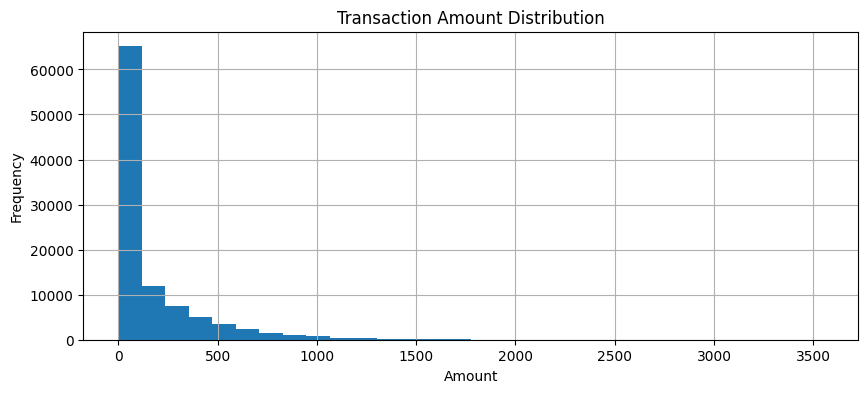

In [13]:
# Amount Distribution
plt.figure(figsize=(10,4))

df["amount"].hist(bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

**Insight:** Transaction amounts are heavily right-skewed, indicating most users perform low-value transactions.

In [14]:
# Helper Function to add value labels (numbers) on top of bars in a bar chart.
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')

#### ii. Monthly Transaction Trends

In [15]:
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly_trends = df.groupby(['year_month', 'month_name']).agg({
    "transaction_id": "count",
    "amount": "sum"
}).rename(columns={
    "transaction_id": "No. of Transactions",
    "amount": "Total_value"
})

monthly_trends["Avg_transaction_value"] = (
    monthly_trends["Total_value"] / monthly_trends["No. of Transactions"]).map(lambda x: f"${x:,.2f}")

monthly_trends["Total_value"]= monthly_trends["Total_value"].map(lambda x: f"${x:,.2f}")



monthly_trends

,,No. of Transactions,Total_value,Avg_transaction_value
year_month,month_name,,,
2022-01,Jan,366,"$56,976.97",$155.67
2022-02,Feb,949,"$160,178.57",$168.79
2022-03,Mar,1800,"$303,968.46",$168.87
2022-04,Apr,2408,"$430,246.17",$178.67
2022-05,May,3078,"$473,746.20",$153.91
2022-06,Jun,3866,"$665,846.81",$172.23
2022-07,Jul,4589,"$754,871.71",$164.50
2022-08,Aug,5442,"$880,712.16",$161.84
2022-09,Sep,5822,"$962,110.65",$165.25


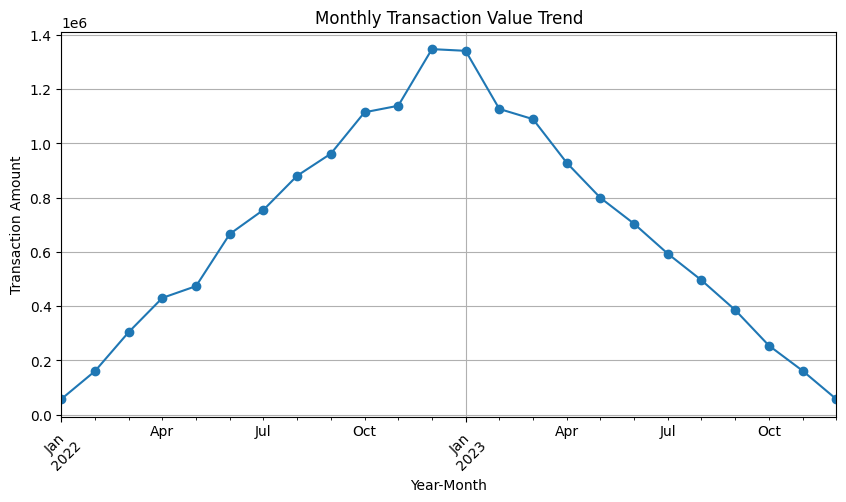

In [16]:
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly_trends = df.groupby('year_month')['amount'].sum()

monthly_trends.plot(marker='o', figsize=(10,5))
plt.grid()
plt.title("Monthly Transaction Value Trend")
plt.xlabel("Year-Month")
plt.ylabel("Transaction Amount")
plt.xticks(rotation=45)
plt.show()

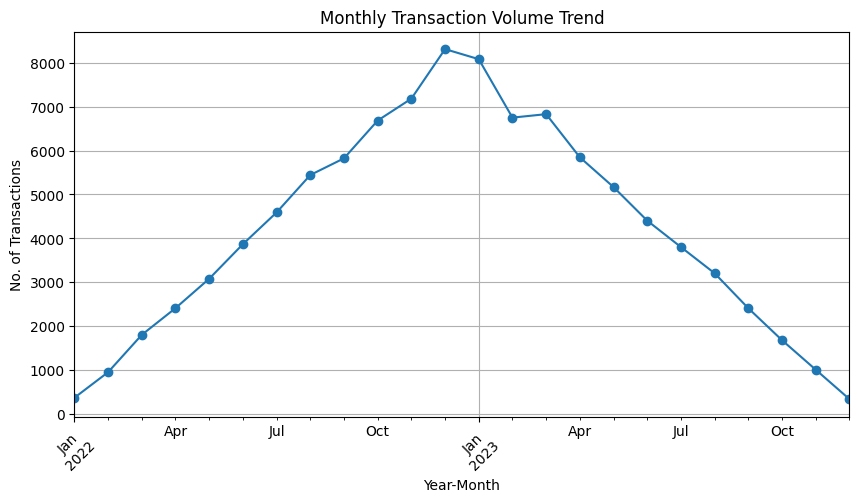

In [17]:
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly_rev = df.groupby('year_month')['transaction_id'].count()

monthly_rev.plot(marker='o', figsize=(10,5))
plt.grid()
plt.title("Monthly Transaction Volume Trend")
plt.xlabel("Year-Month")
plt.ylabel("No. of Transactions")
plt.xticks(rotation=45)
plt.show()

#### iii. Average Daily Trends

In [18]:
df['date'] = df['transaction_date'].dt.date

daily_counts = df.groupby(['date', 'day_name'])['transaction_id'].count().reset_index()

avg_daily_trends = daily_counts.groupby('day_name')['transaction_id'].mean().reset_index()

avg_daily_trends.rename(columns={'transaction_id': 'avg_transactions'}, inplace=True)

order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

avg_daily_trends['day_name'] = pd.Categorical(avg_daily_trends['day_name'], categories=order, ordered=True)
avg_daily_trends = avg_daily_trends.round(0).sort_values('day_name')

avg_daily_trends

,day_name,avg_transactions
1,Mon,137.0
5,Tue,137.0
6,Wed,138.0
4,Thu,137.0
0,Fri,138.0
2,Sat,139.0
3,Sun,137.0


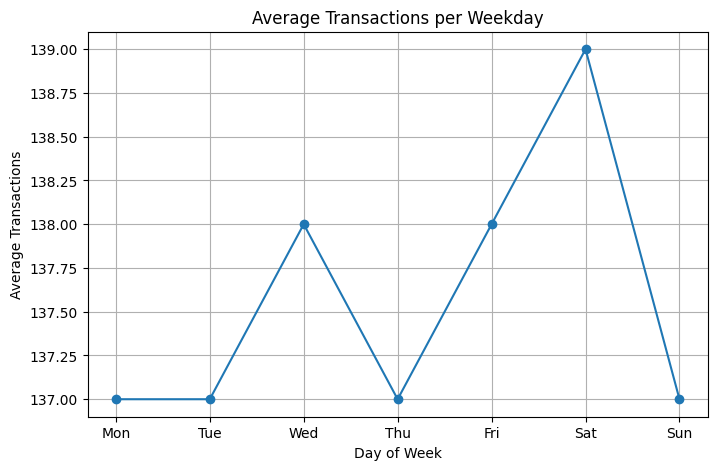

In [19]:
plt.figure(figsize=(8,5))
plt.plot(avg_daily_trends['day_name'], avg_daily_trends['avg_transactions'], marker='o')

plt.title("Average Transactions per Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Average Transactions")
plt.grid()

plt.show()

#### iv. Transaction Volume by Transaction Type

In [20]:
transactions_by_type = df.groupby("transaction_type")["transaction_id"].count()

transactions_by_type.sort_values(ascending=False).reset_index(name="Transaction volume")

,transaction_type,Transaction volume
0,airtime,25123
1,bill_payment,25031
2,merchant_payment,24979
3,transfer,24867


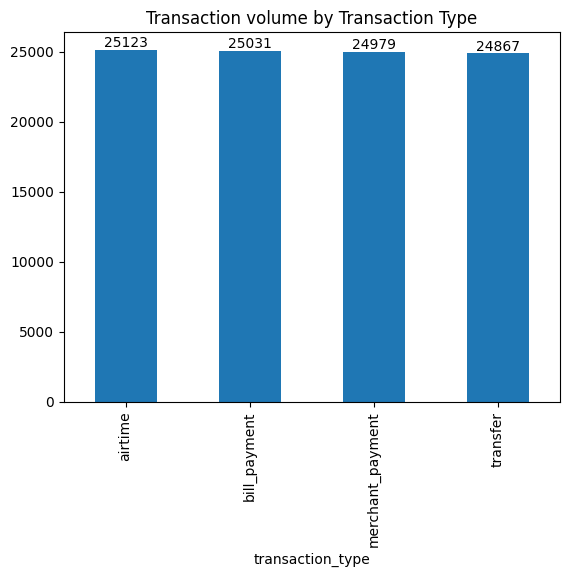

In [21]:
ax = df['transaction_type'].value_counts().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Transaction volume by Transaction Type")
plt.show()

**Insight:** Airtime and bill payment dominate platform usage

#### v. Transactions by Device

In [22]:
transactions_by_device = df.groupby("device_type")["transaction_id"].count()

transactions_by_device.sort_values(ascending=False).reset_index(name="Transaction volume")

,device_type,Transaction volume
0,iOS,33644
1,Web,33526
2,Android,32830


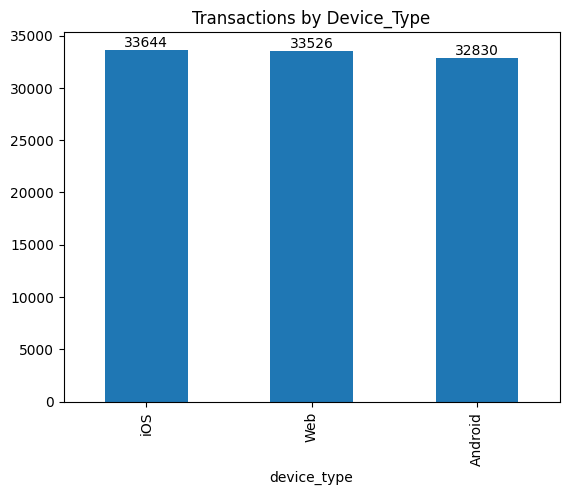

In [23]:
ax = df['device_type'].value_counts().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Transactions by Device_Type")
plt.show()

**Insight:** IOS Devices dominate usage

#### vi. Failed Transactions by Transaction Type

In [24]:
failed_txn_by_type = df.groupby("transaction_type")['failed_txn'].sum()

failed_txn_by_type.sort_values(ascending=False).reset_index(name="Failed Transactions")

,transaction_type,Failed Transactions
0,bill_payment,1295
1,merchant_payment,1279
2,airtime,1271
3,transfer,1265


#### vii. Failed Transactions by Device

In [25]:
failed_txn_by_device = df.groupby("device_type")['failed_txn'].sum()

failed_txn_by_device.sort_values(ascending=False).reset_index(name="Failed Transactions")

,device_type,Failed Transactions
0,iOS,1743
1,Android,1697
2,Web,1670


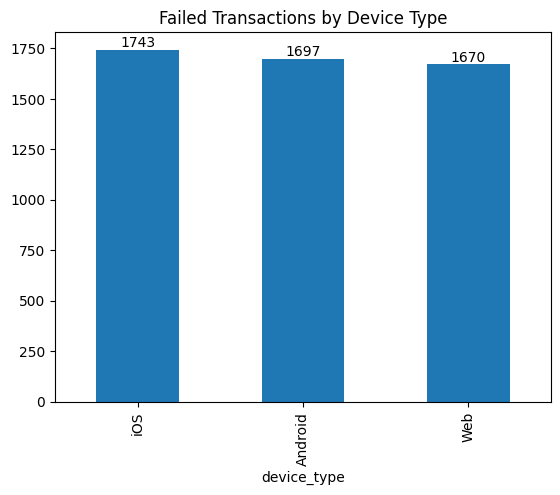

In [26]:
ax = df.groupby('device_type')['failed_txn'].sum().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Failed Transactions by Device Type")
plt.show()

### Key Insight Questions 
- Is transaction volume growing?
- Are users transacting more or just spending more?
- Any spikes (seasonality)?

## 📊 🔍 Overall Trend Summary

- 🚀 **2022 → Strong Growth Phase**  
- 📉 **2023 → Sharp Decline Phase**  

👉 This reflects a classic product lifecycle pattern:  
**Growth → Peak → Decline**

---

## 📈 1. 2022: Rapid Growth & Expansion

#### Key Observations:
- Transactions: **366 → 8,311** 📈  
- Total Value: **$56K → $1.34M** 📈  
- Consistent month-on-month growth  

#### 🧠 Interpretation:
- Product in **growth/scale phase**  
- Increasing user acquisition  
- Rising platform adoption  

👉 Strong acceleration observed in:
- **March → June → October → December**

#### 💡 Business Meaning:
- Marketing & acquisition strategies were effective  
- Likely drivers:
  - Promotions  
  - Market expansion  
  - Increased user trust  

---

## 📊 2. Peak Period (Dec 2022 – Jan 2023)

#### Peak Metrics:
- **Dec 2022:**  
  - 8,311 transactions  
  - $1.34M total value  

- **Jan 2023:**  
  - 8,082 transactions (still very high)  

#### 🧠 Interpretation:
- Peak user activity reached  
- Likely influenced by:
  - Holiday season 🎄  
  - Increased spending behavior  

---

### 📉 3. 2023: Sustained Decline

#### Major Drop:
- Transactions: **8,082 → 335**  
- Revenue: **$1.34M → $57K**  

👉 ~**95% decline** 🚨  

#### 🧠 Interpretation:
This is not normal fluctuation — it indicates:

❗ **Severe user drop-off / retention failure**

#### Possible Causes:
- 🔻 Customer churn (users not returning)  
- 🔻 Reduced acquisition (fewer new users)  
- 🔻 Trust or fraud issues  
- 🔻 Seasonality (minor contributor)  

---

## 💰 4. Average Transaction Value (Key Insight)

#### Observation:
- Stable range: **~$150 – $170**

#### 🧠 Interpretation:
👉 The issue is **NOT spending behavior — it is user activity**

- Remaining users are spending normally  
- But total number of users is **declining sharply**

---

## 🔥 5. Critical Insight

> “The decline in total revenue is primarily driven by a sharp reduction in transaction volume rather than a decrease in average transaction value.”

---

## 📊 6. Business Diagnosis

| Metric        | Trend                  | Meaning                  |
|--------------|-----------------------|--------------------------|
| Transactions | ⬆️ then ⬇️ sharply     | User activity collapse   |
| Revenue      | ⬆️ then ⬇️ sharply     | Driven by volume         |
| Avg Value    | ➡️ Stable              | Spending unchanged       |

---

## 🚨 7. Key Problems Identified

- ❗ **Retention Failure**  
  Users are not returning after initial engagement  

- ❗ **Over-Reliance on Acquisition**  
  Growth driven by new users, not loyal users  

- ❗ **Potential Fraud Impact**  
  Fraud may have:
  - Reduced user trust  
  - Increased churn  

---

## 💼 8. Business Recommendations

#### 📈 Retention Strategy (Top Priority)
- Introduce loyalty programs  
- Offer personalized incentives  
- Improve onboarding experience  

---

#### 🔍 Fraud Control
- Strengthen fraud detection (ML model)  
- Reduce failed transactions  
- Improve transaction security  

---

#### 📢 Re-Engagement Campaigns
- Email/SMS campaigns  
- Discounts for inactive users  
- Targeted promotions  

---

#### 📊 Cohort Monitoring
- Identify:
  - When users drop off  
  - Which segments churn fastest  

---

## 🎯 Executive Insight

The platform experienced strong growth in 2022, reaching peak activity in December. However, 2023 shows a severe decline in transaction volume, indicating a **major retention problem rather than a reduction in user spending behavior**.

👉 Immediate focus should be on:
- Customer retention  
- User re-engagement  
- Improving overall product experience  

### B. FRAUD ANALYSIS
🎯 Goal: Identify fraud patterns and risk areas

### i. Fraud Rate

In [27]:
fraud_rate = df["is_fraud"].mean()
print(f"Fraud Rate: {fraud_rate:.2%}")

Fraud Rate: 1.53%


In [28]:
print(df["is_fraud"].value_counts())

print(df["is_fraud"].value_counts(normalize=True))

is_fraud
0    98466
1     1534
Name: count, dtype: int64
is_fraud
0    0.98466
1    0.01534
Name: proportion, dtype: float64


**Insight:** Fraud cases are rare, confirming strong class imbalance.

### ii. Fraud by Transaction Type

In [29]:
fraud_by_type = df.groupby("transaction_type")["is_fraud"].sum()

fraud_by_type.sort_values(ascending=False).reset_index(name="Fraud volume")

,transaction_type,Fraud volume
0,transfer,1318
1,bill_payment,76
2,airtime,71
3,merchant_payment,69


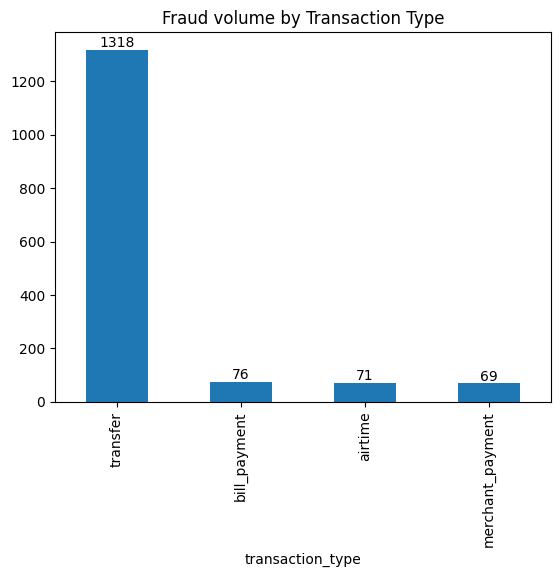

In [30]:
ax = df.groupby('transaction_type')['is_fraud'].sum().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Fraud volume by Transaction Type")
plt.show()

**Insight:** Transfer transactions dominate fraud cases

### iii. Fraud by Device Type

In [31]:
fraud_by_device = df.groupby("device_type")["is_fraud"].sum()

fraud_by_device.sort_values(ascending=False).reset_index(name="Fraud volume")

,device_type,Fraud volume
0,Web,538
1,iOS,509
2,Android,487


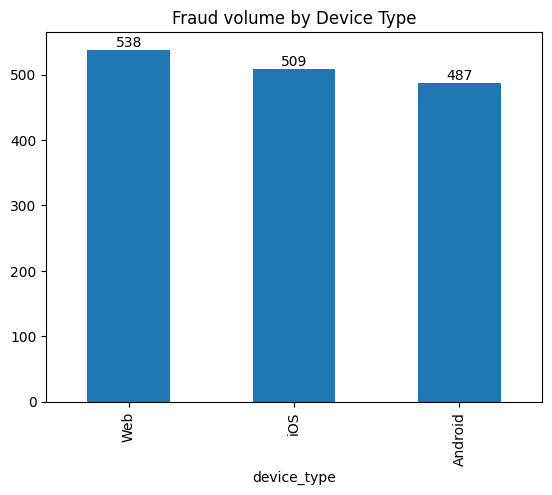

In [32]:
ax = df.groupby('device_type')['is_fraud'].sum().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Fraud volume by Device Type")
plt.show()

Web-based transactions report the highest fraud volume

### iv. Fraud volume by Merchant

In [33]:
fraud_by_merchant = df.groupby("user_id")["is_fraud"].sum()

print("Top 10 Fraud volume by Merchant:")
fraud_by_merchant.sort_values(ascending=False).reset_index(name="Fraud volume").head(10)

Top 10 Fraud volume by Merchant:


,user_id,Fraud volume
0,1170,4
1,1694,3
2,1579,3
3,1116,3
4,1048,3
5,1899,3
6,4450,3
7,3474,3
8,3782,3
9,424,3


### v. High-value fraud

In [34]:
high_value_fraud_volume = df["fraud_high_value"].sum()

print(f"Total High-value Fraud Occurence: {high_value_fraud_volume} cases")

Total High-value Fraud Occurence: 265 cases


In [35]:
high_value_fraud_rate = df["fraud_high_value"].mean()

print(f"High-value Fraud Rate: {high_value_fraud_rate:.2%}")

High-value Fraud Rate: 0.27%


### vii. Transaction Amount vs Fraud Rate

In [36]:
# Create amount ranges/bins
df['amount_bin'] = pd.cut(
    df['amount'],
    bins=[0, 100, 300, 500, 1000, 1500, 2000, float('inf')],
    labels=["$0-$100", "$100-$300", "$300-$500", "$500-$1k", "$1k-$1.5k", "$1.5k-$2k", "$2k+"]
)

# Calculate fraud rate per bin
fraud_by_amount = df.groupby('amount_bin')['is_fraud'].mean().reset_index()
fraud_by_amount.rename(columns={'is_fraud': 'fraud_rate'}, inplace=True)

fraud_by_amount

,amount_bin,fraud_rate
0,$0-$100,0.013290
1,$100-$300,0.017528
2,$300-$500,0.011777
3,$500-$1k,0.012145
4,$1k-$1.5k,0.067159
5,$1.5k-$2k,0.184127
6,$2k+,0.188406


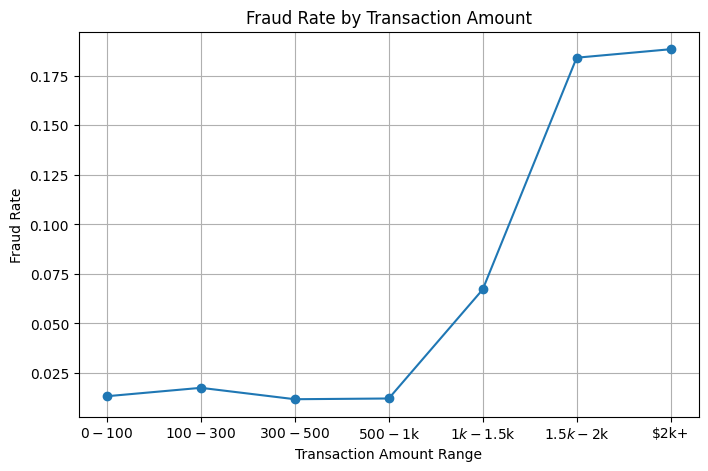

In [37]:
plt.figure(figsize=(8,5))
plt.plot(fraud_by_amount['amount_bin'], fraud_by_amount['fraud_rate'], marker='o')

plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Fraud Rate")
plt.grid()

plt.show()

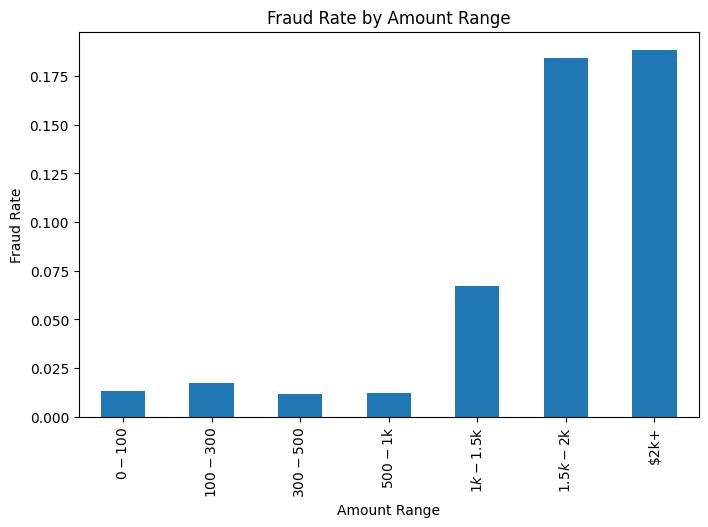

In [38]:
fraud_by_amount.set_index('amount_bin')['fraud_rate'].plot(kind='bar', figsize=(8,5))

plt.title("Fraud Rate by Amount Range")
plt.ylabel("Fraud Rate")
plt.xlabel("Amount Range")
plt.show()

In [39]:
# Fraud rate by Transaction value
df.groupby('transaction_value')['is_fraud'].mean().round(4).mul(100).sort_values(ascending=False).reset_index(name="Fraud Rate ( % )")

,transaction_value,Fraud Rate ( % )
0,High value,2.76
1,Low value,1.41
2,Mid value,1.39


In [40]:
# Fraud rate by Transaction value
df.groupby('transaction_value')['is_fraud'].mean().mul(100)

transaction_value
Low value     1.406912
Mid value     1.390513
High value    2.756684
Name: is_fraud, dtype: float64

**Insight Questions**
- Which transaction type is riskiest?
- Does fraud increase with amount?
- Should certain transactions require extra verification?

**Insights:** 
- Transfer transactions show higher fraud exposure.
- Fraud likelihood increases with transaction amount, with the highest risk observed in transactions above $1,500

### C. REGIONAL ANALYSIS

### i. Transactions by Country

In [41]:
transactions_by_country = df.groupby("country")["transaction_id"].count()

transactions_by_country.sort_values(ascending=False).reset_index(name="Transaction volume")

,country,Transaction volume
0,Kenya,25887
1,South Africa,25334
2,Ghana,24487
3,Nigeria,24292


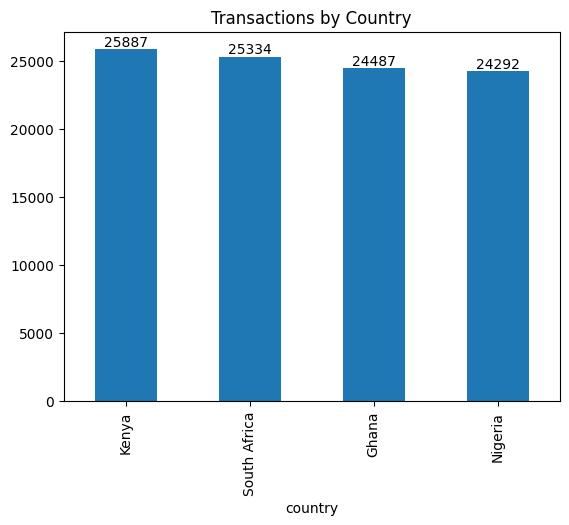

In [42]:
ax = df['country'].value_counts().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Transactions by Country")
plt.show()

### ii. Fraud volume by Country

In [43]:
fraud_by_country = df.groupby("country")["is_fraud"].sum()

fraud_by_country.sort_values(ascending=False).reset_index(name="Fraud volume")

,country,Fraud volume
0,Ghana,400
1,Kenya,384
2,South Africa,379
3,Nigeria,371


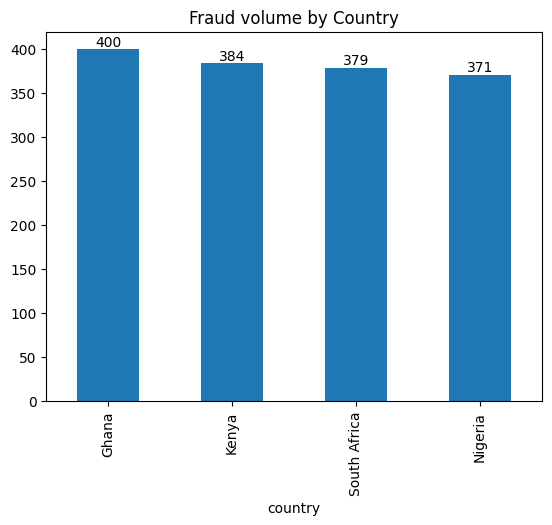

In [44]:
ax = df.groupby('country')['is_fraud'].sum().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Fraud volume by Country")
plt.show()

In [45]:
fraud_rate_by_country = (
    df.groupby("country")["is_fraud"].mean()
    .mul(100)  # convert to %
    .round(2)
    .sort_values(ascending=False)
    .reset_index(name="Fraud Rate (%)")
)

fraud_rate_by_country

,country,Fraud Rate (%)
0,Ghana,1.63
1,Nigeria,1.53
2,South Africa,1.50
3,Kenya,1.48


- Kenya & South Africa dominate transaction volume
- Ghana experiences the highest fraud rate

### D. USER SEGMENTATION (RFM)
🎯 Goal: Identify high-value vs low-value users

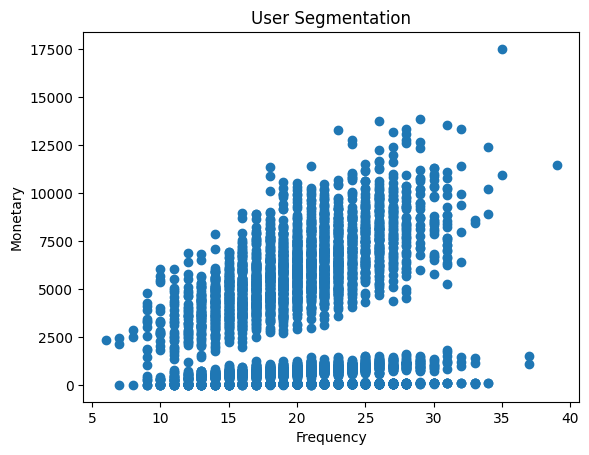

In [46]:
snapshot = df["transaction_date"].max()

rfm = df.groupby("user_id").agg({
    "transaction_date": lambda x: (snapshot - x.max()).days,
    "transaction_id": "count",
    "amount": "sum"
})

rfm.columns = ["recency", "frequency", "monetary"]

plt.scatter(rfm["frequency"], rfm["monetary"])
plt.title("User Segmentation")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()


In [47]:
rfm["segment"] = pd.qcut(rfm["monetary"], 4, labels=[
    "Low Value", "Mid Value", "High Value", "VIP"
])

rfm["monetary"] = rfm["monetary"].map(lambda x: f"${x:,.2f}")
rfm.head()

,recency,frequency,monetary,segment
user_id,,,,
1,264,23,"$7,947.34",VIP
2,31,21,"$7,271.18",VIP
3,107,20,"$6,923.42",VIP
4,290,23,$55.50,Low Value
5,304,18,"$1,025.36",Mid Value


In [48]:
# Total Revenue by Segment
rfm_reset = rfm.reset_index()
data = df.merge(rfm_reset[["user_id", "segment"]], on="user_id")

revenue_segment = data.groupby("segment")["fee_amount"].sum()

revenue_segment = revenue_segment.map(lambda x: f"${x:,.2f}")

revenue_segment.reset_index(name="Revenue")

,segment,Revenue
0,Low Value,"$1,044.60"
1,Mid Value,"$11,468.68"
2,High Value,"$66,911.80"
3,VIP,"$113,966.75"


In [49]:
rfm[rfm["frequency"] < 20]

,recency,frequency,monetary,segment
user_id,,,,
5,304,18,"$1,025.36",Mid Value
9,253,18,$42.79,Low Value
11,63,16,$655.88,Mid Value
12,279,11,"$1,362.80",Mid Value
16,273,15,$686.40,Mid Value
...,...,...,...,...
4992,70,16,"$4,127.64",High Value
4995,135,18,$689.15,Mid Value
4997,10,18,$68.75,Low Value


In [50]:
rfm[rfm["segment"] == "VIP"]

,recency,frequency,monetary,segment
user_id,,,,
1,264,23,"$7,947.34",VIP
2,31,21,"$7,271.18",VIP
3,107,20,"$6,923.42",VIP
7,367,23,"$8,083.42",VIP
13,275,20,"$6,185.59",VIP
...,...,...,...,...
4977,265,25,"$9,585.41",VIP
4981,84,24,"$6,650.59",VIP
4984,324,19,"$6,053.93",VIP


In [51]:
rfm.groupby('segment').size().reset_index(name="user_count")

,segment,user_count
0,Low Value,1250
1,Mid Value,1250
2,High Value,1250
3,VIP,1250


**Insight Questions**
- What % of users are VIP?
- Do a small number of users drive most revenue?

**Insight:** A small percentage of users drive the majority of revenue.

### E. RETENTION ANALYSIS
🎯 Goal: Understand user retention over time

In [52]:
# Cohort Features

# Create month period
df['month'] = df['transaction_date'].dt.to_period('M')

# Cohort month (first transaction per user)
df['cohort_month'] = df.groupby('user_id')['transaction_date'] .transform('min') .dt.to_period('M')

# Cohort index (months since first transaction)
df['cohort_index'] = (df['month'] - df['cohort_month']).apply(lambda x: x.n)

### i. Retention Table

In [53]:
cohort_table = df.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='user_id',
    aggfunc='nunique'
)

# Normalize
cohort_size = cohort_table.iloc[:, 0]
retention = cohort_table.divide(cohort_size, axis=0)

retention


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2022-01,1.0,0.789474,0.850877,0.798246,0.842105,0.793860,0.798246,0.802632,0.811404,0.771930,0.811404,0.859649,0.399123
2022-02,1.0,0.818713,0.801170,0.809942,0.812865,0.807018,0.783626,0.827485,0.786550,0.792398,0.836257,0.733918,0.192982
2022-03,1.0,0.833724,0.817330,0.777518,0.845433,0.831382,0.805621,0.852459,0.791569,0.836066,0.822014,0.648712,0.224824
2022-04,1.0,0.805419,0.802956,0.834975,0.849754,0.825123,0.785714,0.817734,0.805419,0.825123,0.815271,0.687192,0.197044
2022-05,1.0,0.814727,0.819477,0.824228,0.824228,0.817102,0.833729,0.819477,0.809976,0.764846,0.826603,0.643705,0.197150
2022-06,1.0,0.801782,0.792873,0.801782,0.835189,0.799555,0.815145,0.826281,0.752784,0.835189,0.766147,0.643653,0.200445
2022-07,1.0,0.820513,0.807692,0.782051,0.828205,0.843590,0.830769,0.828205,0.794872,0.756410,0.764103,0.610256,0.194872
2022-08,1.0,0.802632,0.824561,0.798246,0.855263,0.828947,0.811404,0.809211,0.811404,0.791667,0.769737,0.679825,0.223684
2022-09,1.0,0.791557,0.788918,0.852243,0.841689,0.765172,0.828496,0.825858,0.810026,0.807388,0.788918,0.680739,0.205805


### ii. Cohort Size Table

In [54]:
cohort_table

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2022-01,228.0,180.0,194.0,182.0,192.0,181.0,182.0,183.0,185.0,176.0,185.0,196.0,91.0
2022-02,342.0,280.0,274.0,277.0,278.0,276.0,268.0,283.0,269.0,271.0,286.0,251.0,66.0
2022-03,427.0,356.0,349.0,332.0,361.0,355.0,344.0,364.0,338.0,357.0,351.0,277.0,96.0
2022-04,406.0,327.0,326.0,339.0,345.0,335.0,319.0,332.0,327.0,335.0,331.0,279.0,80.0
2022-05,421.0,343.0,345.0,347.0,347.0,344.0,351.0,345.0,341.0,322.0,348.0,271.0,83.0
2022-06,449.0,360.0,356.0,360.0,375.0,359.0,366.0,371.0,338.0,375.0,344.0,289.0,90.0
2022-07,390.0,320.0,315.0,305.0,323.0,329.0,324.0,323.0,310.0,295.0,298.0,238.0,76.0
2022-08,456.0,366.0,376.0,364.0,390.0,378.0,370.0,369.0,370.0,361.0,351.0,310.0,102.0
2022-09,379.0,300.0,299.0,323.0,319.0,290.0,314.0,313.0,307.0,306.0,299.0,258.0,78.0


### iii. Retention Cohort Plot

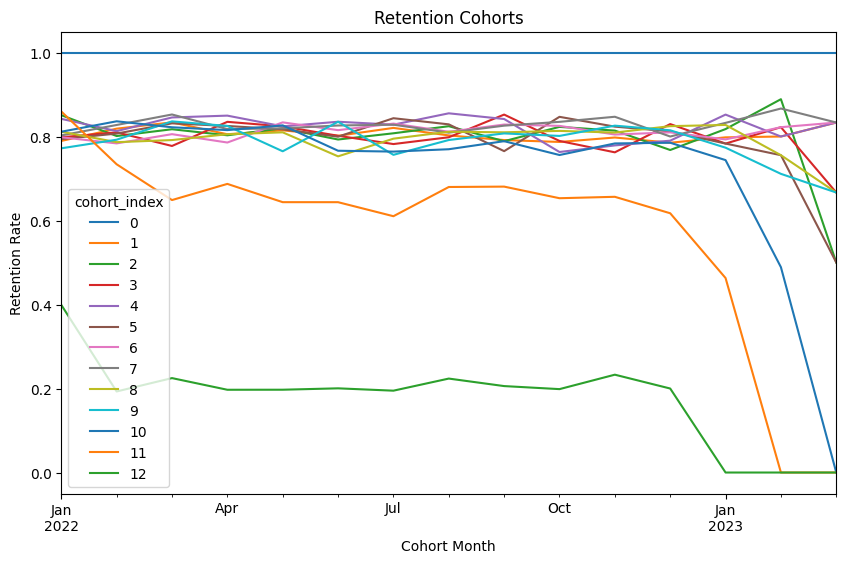

In [55]:
import matplotlib.pyplot as plt

retention.fillna(0).plot(figsize=(10,6))
plt.title("Retention Cohorts")
plt.ylabel("Retention Rate")
plt.xlabel("Cohort Month")
plt.show()

### iv. Retention Cohort Heatmap

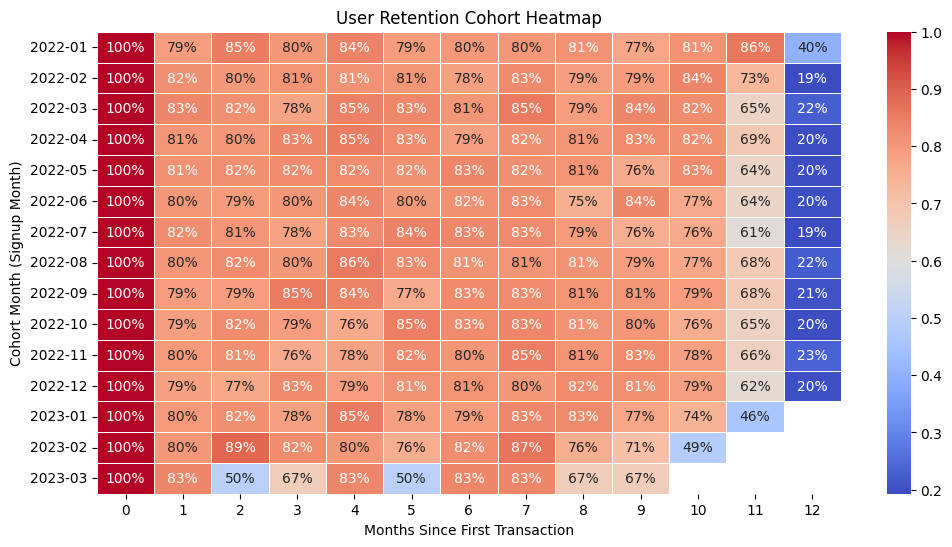

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("User Retention Cohort Heatmap")
plt.ylabel("Cohort Month (Signup Month)")
plt.xlabel("Months Since First Transaction")

plt.show()

**How to Read the Heatmap**

- Each row = users who joined in the same month
- Each column = how many months later

Example:

- Row: Jan 2023
- Column 0 → 100% (all users)
- Column 1 → % who returned next month
- Column 2 → % who returned after 2 months

### v. Average Retention Rate by Country

In [57]:
# Cohort table
cohort_country = df.pivot_table(
    index=['cohort_month', 'country'],
    columns='cohort_index',
    values='user_id',
    aggfunc='nunique'
)

# Normalize
cohort_size = cohort_country.iloc[:, 0]
retention_country = cohort_country.divide(cohort_size, axis=0)

# Reset index
retention_country = retention_country.reset_index()

# Drop cohort_month
retention_country = retention_country.drop(columns=['cohort_month'])

# Average across all periods
retention_country = retention_country.groupby('country').mean()

# Get ONE value per country
retention_country = retention_country.mean(axis=1)

# Convert to %
retention_country = (retention_country * 100).round(2).astype(str) + '%'

retention_country.reset_index(name="Avg Retention rate")

,country,Avg Retention rate
0,Ghana,76.69%
1,Kenya,76.47%
2,Nigeria,76.38%
3,South Africa,76.32%


### vi. Average Retention Rate by Device Type

In [58]:
# Cohort table
cohort_device = df.pivot_table(
    index=['cohort_month', 'device_type'],
    columns='cohort_index',
    values='user_id',
    aggfunc='nunique'
)

# Normalize
cohort_size = cohort_device.iloc[:, 0]
retention_device = cohort_device.divide(cohort_size, axis=0)

# Reset index
retention_device = retention_device.reset_index()

# Drop cohort_month
retention_device = retention_device.drop(columns=['cohort_month'])

# Average across all periods
retention_device = retention_device.groupby('device_type').mean()

# Get ONE value per device
retention_device = retention_device.mean(axis=1)

# Convert to %
retention_device = (retention_device * 100).round(2).astype(str) + '%'

retention_device.sort_values(ascending=False).reset_index(name="Avg Retention rate")

,device_type,Avg Retention rate
0,iOS,77.02%
1,Web,76.77%
2,Android,75.54%


### vii. Average Retention Rate by Acquisition Channel

In [59]:
# Cohort table
cohort_channel = df.pivot_table(
    index=['cohort_month', 'acquisition_channel'],
    columns='cohort_index',
    values='user_id',
    aggfunc='nunique'
)

# Normalize
cohort_size = cohort_channel.iloc[:, 0]
retention_channel = cohort_channel.divide(cohort_size, axis=0)

# Reset index
retention_channel = retention_channel.reset_index()

# Drop cohort_month
retention_channel = retention_channel.drop(columns=['cohort_month'])

# Average across all periods
retention_channel = retention_channel.groupby('acquisition_channel').mean()

# Get ONE value per channel
retention_channel = retention_channel.mean(axis=1)

# Convert to %
retention_channel = (retention_channel * 100).round(2).astype(str) + '%'

retention_channel.sort_values(ascending=False).reset_index(name="Avg Retention rate")

,acquisition_channel,Avg Retention rate
0,Organic,76.34%
1,Ads,76.21%
2,Referral,75.79%


## 📉 Key Retention Insights

---

### **1. Sharp Drop After Month 1**
_Retention drops significantly after the first month, indicating weak early user engagement._

👉 Meaning:
- Users try the product once and don’t return  
- Onboarding experience may be poor  

---

### **2. Stabilization After Initial Drop**
_Retention stabilizes after the first few months, suggesting a core group of loyal users._

👉 Meaning:
- Users who stay past Month 2 are high-value users  

---

### **3. Minimal Variation Across Countries**
_Average retention is very similar across all countries (~76%), with Ghana slightly leading (76.69%)._

👉 Meaning:
- Retention challenges are **not country-specific**  
- The issue is likely **product-wide rather than market-specific**  
- Growth strategies should focus on **global product improvements**, not just geographic optimization  

---

### **4. Device Impact is Slight but Not Significant**
_iOS shows the highest retention (77.02%), while Android is slightly lower (75.54%)._

👉 Meaning:
- Device type has **minor influence on retention**  
- Slightly lower Android retention may indicate:
  - Performance issues  
  - UX inconsistencies  
- Overall, retention problems are **not primarily device-driven**  

---

### **5. Acquisition Channels Show Similar Retention Quality**
_Organic (76.34%), Ads (76.21%), and Referral (75.79%) users have nearly identical retention rates._

👉 Meaning:
- No channel is significantly outperforming others  
- The problem is **post-acquisition (product experience)**, not acquisition quality  
- Scaling acquisition without fixing retention will lead to **wasted marketing spend**  

---

### **6. Long-Term Retention is Low**
_Few users remain active after several months, highlighting churn challenges._

👉 Meaning:
- Product lacks long-term stickiness  
- Users are not finding enough value to stay engaged  

---

## 💼 Business / Actionable Recommendations (Enhanced)

---

### 🚀 Improve Early User Experience (Critical)
- Optimize onboarding flow (first 7 days are crucial)  
- Introduce **guided onboarding or walkthroughs**  
- Offer **first-transaction incentives**  

---

### 🔁 Strengthen Retention Mechanisms
- Use push notifications, emails, and reminders for inactive users  
- Introduce **habit-forming features** (e.g., rewards, streaks, recurring actions)  
- Implement **personalized user experiences**  

---

### ⚙️ Product-Level Optimization (High Priority)
- Since retention is consistent across:
  - Countries  
  - Devices  
  - Channels  

👉 Focus on:
- Core product value proposition  
- UX improvements  
- Transaction success experience  

---

### 📱 Device Optimization (Secondary)
- Investigate slightly lower Android retention  
- Ensure consistent performance across devices  

---

### 📢 Smarter Growth Strategy
- Avoid over-investing in acquisition until retention improves  
- Focus on **retention-first growth**  
- Double down on **user engagement, not just user acquisition**  

---

### 🔄 Re-Engagement Strategy
- Target churned users with:
  - Discounts  
  - Promotions  
  - Feature updates  
- Use lifecycle marketing campaigns  

---

## 🎯 Executive Insight

Retention performance is **uniform across countries, devices, and acquisition channels**, indicating that churn is driven primarily by **product experience rather than user source or demographics**.

While early retention drop remains a critical issue, the lack of segmentation variance confirms that **improving core product engagement and onboarding will have the highest impact on overall retention and long-term growth**.

### v. Cohort by Segment

In [60]:
# Cohort by Segment (shows which transaction types drive retention)

cohort_by_segment = df.groupby(['cohort_month', 'transaction_type'])['user_id'].nunique()

cohort_by_segment

cohort_month  transaction_type
2022-01       airtime             228
              bill_payment        227
              merchant_payment    228
              transfer            227
2022-02       airtime             339
              bill_payment        339
              merchant_payment    341
              transfer            339
2022-03       airtime             419
              bill_payment        426
              merchant_payment    425
              transfer            426
2022-04       airtime             404
              bill_payment        405
              merchant_payment    404
              transfer            405
2022-05       airtime             413
              bill_payment        419
              merchant_payment    418
              transfer            414
2022-06       airtime             447
              bill_payment        448
              merchant_payment    442
              transfer            444
2022-07       airtime             387
              bill_

**Insight Questions**
- Do users drop off after month 1?
- Are newer cohorts better or worse?

**Insight:** Significant drop-off occurs after first month, indicating onboarding issues.

### F. REVENUE ANALYSIS
🎯 Goal: Understand monetization

### i. ARPU (Average Revenue per User) & Total Revenue

In [61]:
total_revenue = df["fee_amount"].sum()
total_users = df["user_id"].nunique()

arpu = total_revenue / total_users

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"ARPU: ${arpu:.2f}")

Total Revenue: $193,391.83
ARPU: $38.68


### ii. Revenue by Segment

In [62]:
rfm_reset = rfm.reset_index()
data = df.merge(rfm_reset[["user_id", "segment"]], on="user_id")

revenue_segment = data.groupby("segment")["fee_amount"].sum()

revenue_segment = revenue_segment.map(lambda x: f"${x:,.2f}")

revenue_segment.reset_index(name="Revenue")

,segment,Revenue
0,Low Value,"$1,044.60"
1,Mid Value,"$11,468.68"
2,High Value,"$66,911.80"
3,VIP,"$113,966.75"


### iii. Monthly Revenue Trend

In [63]:
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly_rev = df.groupby(['year_month', 'month_name'])['fee_amount'].sum().map(lambda x: f"${x:,.2f}")

monthly_rev.reset_index(name= 'Total Revenue')

,year_month,month_name,Total Revenue
0,2022-01,Jan,$685.31
1,2022-02,Feb,"$1,862.65"
2,2022-03,Mar,"$3,688.97"
3,2022-04,Apr,"$5,187.43"
4,2022-05,May,"$5,740.88"
5,2022-06,Jun,"$7,939.03"
6,2022-07,Jul,"$9,096.13"
7,2022-08,Aug,"$10,461.25"
8,2022-09,Sep,"$11,293.03"
9,2022-10,Oct,"$13,322.02"


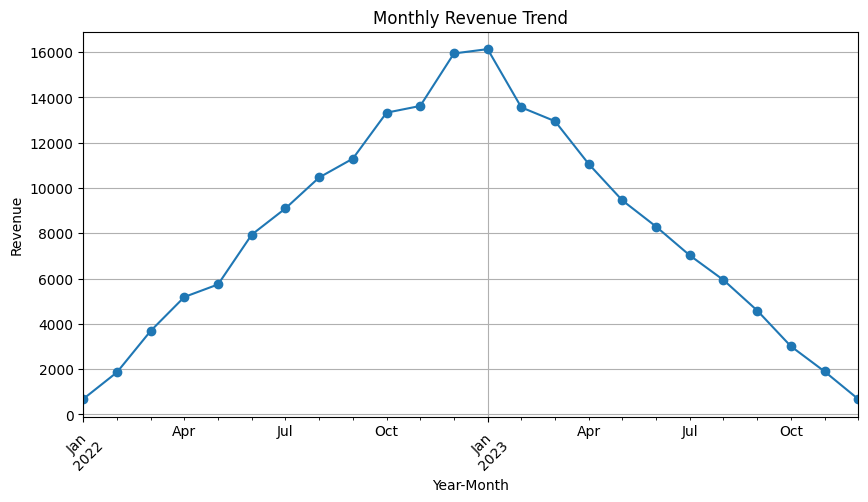

In [64]:
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly_rev = df.groupby('year_month')['fee_amount'].sum()

monthly_rev.plot(marker='o', figsize=(10,5))
plt.grid()
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### iv. Revenue by Transaction Type

In [65]:
revenue_by_txn_type = df.groupby('transaction_type')['fee_amount'].sum().sort_values(ascending=False).map(lambda x: f"${x:,.2f}")
revenue_by_txn_type.reset_index(name= 'Total Revenue')

,transaction_type,Total Revenue
0,airtime,"$48,798.80"
1,bill_payment,"$48,258.61"
2,transfer,"$48,220.01"
3,merchant_payment,"$48,114.41"


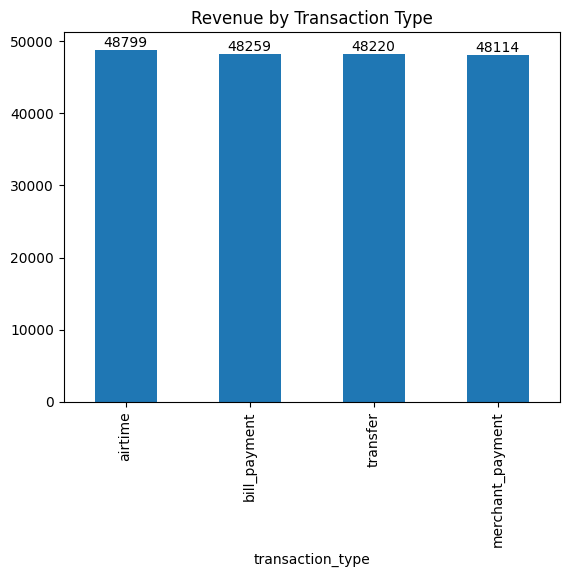

In [66]:
ax = df.groupby('transaction_type')['fee_amount'].sum().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Revenue by Transaction Type")
plt.show()

**Insight:** Revenue is evenly spread amongst transaction types

### v. Revenue by Country

In [67]:
rev_by_country = df.groupby('country')['fee_amount'].sum().sort_values(ascending=False).map(lambda x: f"${x:,.2f}")
rev_by_country.reset_index(name= 'Total Revenue')

,country,Total Revenue
0,Ghana,"$96,828.94"
1,South Africa,"$83,753.21"
2,Kenya,"$11,851.29"
3,Nigeria,$958.39


In [68]:
# Calculate the percentage of total revenue per country
rev_pct_by_country = (df.groupby('country')['fee_amount'].sum() / df['fee_amount'].sum() * 100)

rev_pct_by_country = rev_pct_by_country.sort_values(ascending=False).map(lambda x: f"{x:.1f}%").reset_index(name='Total Revenue %')

rev_pct_by_country

,country,Total Revenue %
0,Ghana,50.1%
1,South Africa,43.3%
2,Kenya,6.1%
3,Nigeria,0.5%


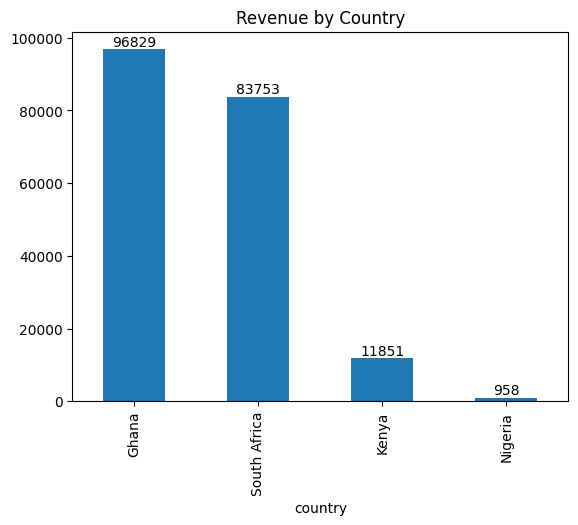

In [69]:
ax = df.groupby('country')['fee_amount'].sum().sort_values(ascending=False).plot(kind='bar')
add_labels(ax)
plt.title("Revenue by Country")
plt.show()

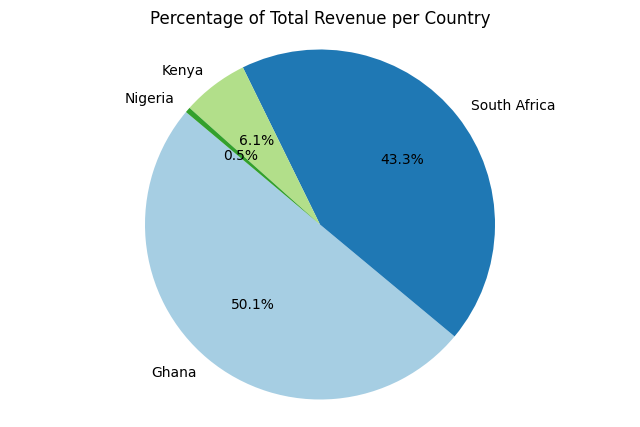

In [70]:
import matplotlib.pyplot as plt

rev_by_country = df.groupby('country')['fee_amount'].sum().sort_values(ascending=False)


plt.figure(figsize=(8, 5))
plt.pie(
    rev_by_country, 
    labels=rev_by_country.index, 
    autopct='%1.1f%%',  # This adds the percentage labels automatically
    startangle=140, 
    colors=plt.cm.Paired.colors
)

plt.title('Percentage of Total Revenue per Country')
plt.axis('equal') # Ensures the pie is drawn as a circle
plt.show()


**Insight:** Ghana & South Africa account for about 93% of Total Revenue while Nigeria contributes less than 1% to Total Revenue

### vi. Month-over-Month (MoM) Growth

In [71]:
# Monthly Revenue
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly_rev = df.groupby('year_month')['fee_amount'].sum().sort_index()

# Convert to Dataframe
monthly_rev = monthly_rev.to_frame(name='revenue').round(2)


monthly_rev['MoM_growth_%'] = monthly_rev['revenue'].pct_change().round(4) * 100

# Absolute Revenue Change
monthly_rev['revenue_change'] = monthly_rev['revenue'].diff().map(lambda x: f"${x:,.2f}")

monthly_rev

,revenue,MoM_growth_%,revenue_change
year_month,,,
2022-01,685.31,NaN,$nan
2022-02,1862.65,171.80,"$1,177.34"
2022-03,3688.97,98.05,"$1,826.32"
2022-04,5187.43,40.62,"$1,498.46"
2022-05,5740.88,10.67,$553.45
2022-06,7939.03,38.29,"$2,198.15"
2022-07,9096.13,14.57,"$1,157.10"
2022-08,10461.25,15.01,"$1,365.12"
2022-09,11293.03,7.95,$831.78


### vii. Revenue Growth Plot

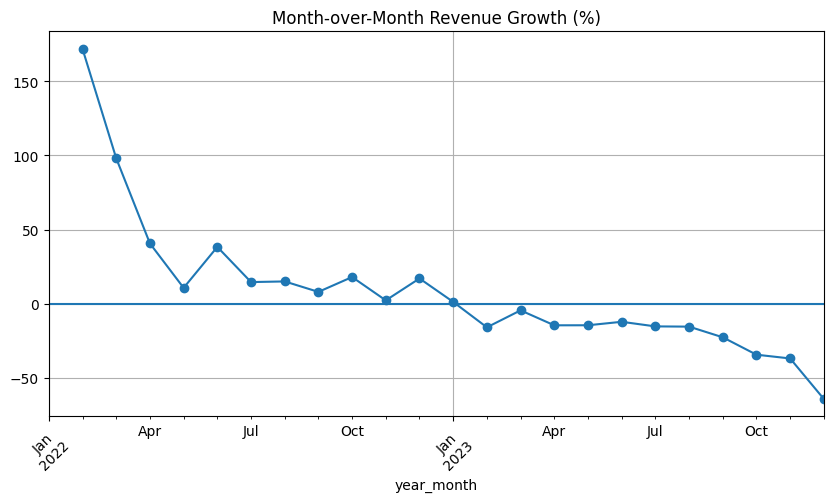

In [72]:
# MoM Growth
monthly_rev['MoM_growth_%'].plot(marker='o', figsize=(10,5))
plt.axhline(0)  # baseline
plt.title("Month-over-Month Revenue Growth (%)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

### viii. Monthly Rolling Average

In [73]:
monthly_rev['rolling_avg'] = monthly_rev['revenue'].rolling(window=3).mean()

monthly_rev['rolling_avg'].map(lambda x: f"${x:,.2f}").reset_index(name="Rolling Average")

,year_month,Rolling Average
0,2022-01,$nan
1,2022-02,$nan
2,2022-03,"$2,078.98"
3,2022-04,"$3,579.68"
4,2022-05,"$4,872.43"
5,2022-06,"$6,289.11"
6,2022-07,"$7,592.01"
7,2022-08,"$9,165.47"
8,2022-09,"$10,283.47"
9,2022-10,"$11,692.10"


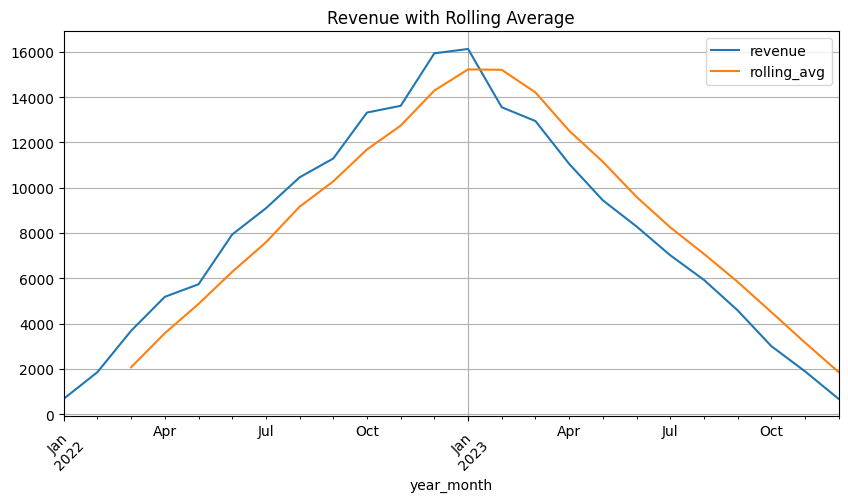

In [74]:
monthly_rev[['revenue', 'rolling_avg']].plot(figsize=(10,5))
plt.title("Revenue with Rolling Average")
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Insight Questions**
- Which users generate the most revenue?
- Is revenue concentrated in a small segment?

## 📊 Revenue Insights

### 🌍 Revenue Concentration (Geography)
- Revenue is heavily concentrated in **Ghana (50.1%)** and **South Africa (43.3%)**, contributing over **93% combined**
- Kenya and Nigeria contribute negligibly (**<7%**)

👉 **Insight:**  
The business is highly dependent on two markets, creating geographic risk and limited diversification.

---

### 📈 Growth Trend (MoM Analysis)
- Strong growth in **2022**, with peak momentum between **June–December**
- Growth slows in early 2023 and turns **consistently negative from February onward**
- Severe contraction in late 2023 (**-34% to -64% MoM**)

👉 **Insight:**  
The business transitioned from rapid expansion to sustained decline, indicating retention or demand collapse, not just seasonal fluctuation.

---

### 📉 Revenue Stability (Rolling Average)
- Rolling average shows steady growth throughout **2022**
- Peaks around early **2023**, then enters a continuous downward trend

👉 **Insight:**  
Revenue momentum was strong but not sustained, confirming a structural decline rather than short-term volatility.

---

### 💰 Revenue Segmentation
- **VIP:** $113,966.75 (highest contributor)  
- **High Value:** $66,911.80  
- **Mid Value:** $11,468.68  
- **Low Value:** $1,044.60  

👉 **Insight:**  
Revenue is highly concentrated among VIP and high-value users, with minimal contribution from lower segments.

---

## 🚨 Key Business Risks
- Over-reliance on few countries  
- Heavy dependence on high-value/VIP users  
- Sustained negative growth in 2023  
- Weak contribution from broader user base  

---

## 💼 Business Recommendations

### 🌍 Market Expansion
- Invest in Kenya & Nigeria growth strategies  
- Reduce dependency on Ghana & South Africa  

---

### 👥 Retention Strategy (Critical)
- Focus on retaining VIP & high-value users  
- Introduce loyalty and incentive programs  

---

### 📉 Revenue Recovery
- Investigate causes of post-Jan 2023 decline  
- Launch reactivation campaigns for inactive users  

---

### ⚖️ Revenue Diversification
- Increase monetization from mid and low-value segments  
- Introduce tiered pricing or upsell strategies  

---

### 📊 Growth Monitoring
- Track MoM growth early warning signals  
- Act quickly on consecutive negative growth periods  

---

## 🎯 Executive Insight
Revenue growth in 2022 was strong but unsustainable, with a sharp decline in 2023 driven by over-reliance on a few markets and high-value users. Long-term stability depends on improving retention and diversifying both geography and customer segments.

# =====================================================================

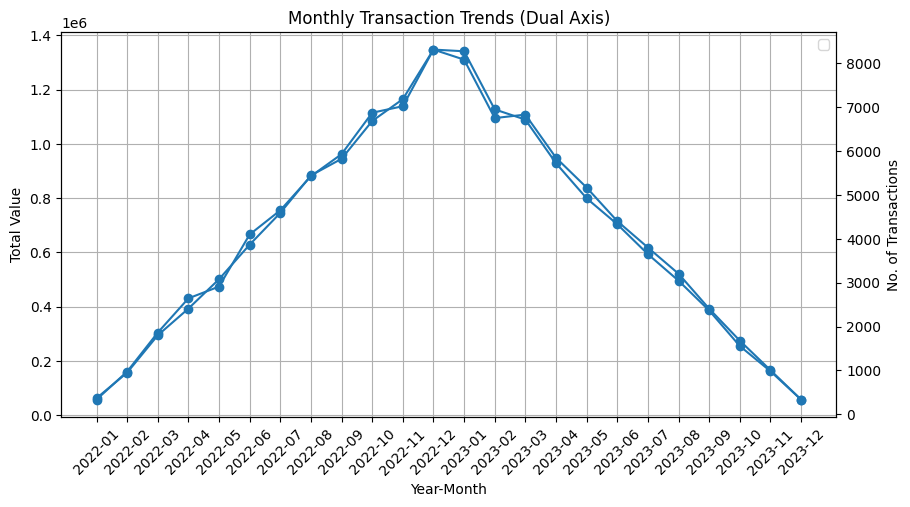

In [75]:
# Transaction volume vs Transaction value Trend

import matplotlib.pyplot as plt

# Ensure correct index
df['year_month'] = df['transaction_date'].dt.to_period('M')

monthly_trends = df.groupby('year_month').agg({
    "transaction_id": "count",
    "amount": "sum"
}).rename(columns={ 
    "transaction_id": "No. of Transactions",
    "amount": "Total Value"
})

monthly_trends.index = monthly_trends.index.astype(str)

# Create figure
fig, ax1 = plt.subplots(figsize=(10,5))

# First axis → Revenue
ax1.plot(monthly_trends.index, monthly_trends['Total Value'], marker='o')
ax1.set_ylabel("Total Value")
ax1.set_xlabel("Year-Month")

# Second axis → Transactions
ax2 = ax1.twinx()
ax2.plot(monthly_trends.index, monthly_trends['No. of Transactions'], marker='o')
ax2.set_ylabel("No. of Transactions")

# Formatting
plt.title("Monthly Transaction Trends (Dual Axis)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid()

# Legend (combined)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, ["Total Value", "No. of Transactions"])

plt.show()

In [76]:
categorical_cols = df.select_dtypes(include= ["object", "category"])

categorical_cols.columns

Index(['transaction_type', 'status', 'country', 'device_type',
       'acquisition_channel', 'month_name', 'day_name', 'transaction_value',
       'date', 'amount_bin'],
      dtype='object')

In [77]:
non_categorical_cols = df.select_dtypes(exclude= ["object", "category"])

non_categorical_cols.columns

Index(['transaction_id', 'user_id', 'transaction_date',
       'amount_local_currency', 'is_fraud', 'fee_amount_local_currency',
       'signup_date', 'exchange_rate', 'amount', 'fee_amount', 'year', 'month',
       'day', 'user_txn_count', 'user_avg_amount', 'profit_margin',
       'failed_txn', 'amount_vs_avg', 'fraud_high_value', 'year_month',
       'cohort_month', 'cohort_index'],
      dtype='object')

In [78]:
numeric_cols = df.select_dtypes(include= ["number"])

numeric_cols.columns

Index(['transaction_id', 'user_id', 'amount_local_currency', 'is_fraud',
       'fee_amount_local_currency', 'exchange_rate', 'amount', 'fee_amount',
       'year', 'day', 'user_txn_count', 'user_avg_amount', 'profit_margin',
       'failed_txn', 'amount_vs_avg', 'fraud_high_value', 'cohort_index'],
      dtype='object')

### Correlation Matrix

In [79]:
useful_cols = ['amount', 'fee_amount', 'is_fraud', 'user_txn_count', 'user_avg_amount',
    'amount_vs_avg', 'failed_txn', 'fraud_high_value', 'profit_margin', 'cohort_index'
]

numeric_df = df[useful_cols]

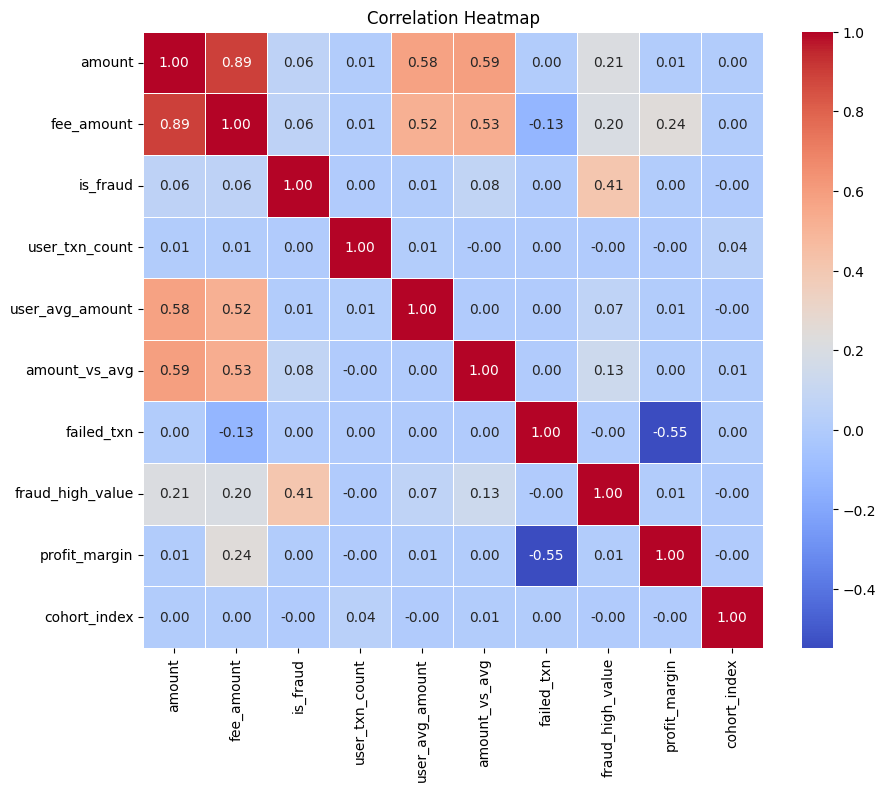

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

### Fraud Correlation

In [81]:
fraud_corr = numeric_df.corr()['is_fraud'].sort_values(ascending=False)

fraud_corr

is_fraud            1.000000
fraud_high_value    0.412981
amount_vs_avg       0.080392
amount              0.062144
fee_amount          0.060477
user_avg_amount     0.007129
profit_margin       0.002943
user_txn_count      0.002251
failed_txn          0.000226
cohort_index       -0.001506
Name: is_fraud, dtype: float64

Interpretation:
- Positive correlation → increases fraud likelihood
- Negative correlation → reduces fraud likelihood
- Near 0 → weak relationship

NB: Correlation ≠ Causation

👉 Just because something correlates:
- Doesn’t mean it causes fraud
- But it’s useful for feature selection in ML

Example Insight

“High-value transactions and failed transaction attempts show stronger correlation with fraud, indicating behavioral risk patterns.”

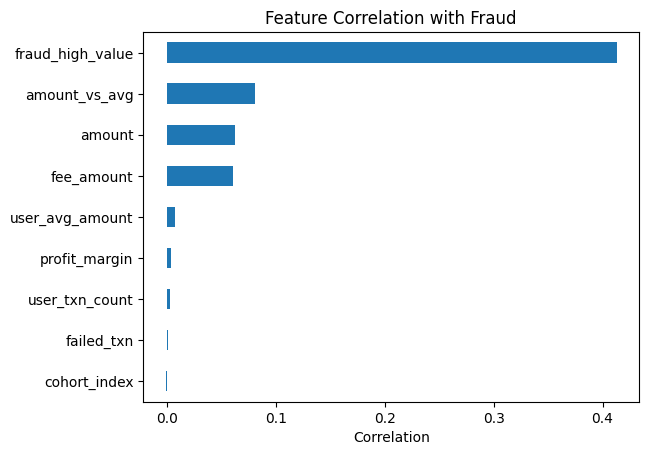

In [82]:
fraud_corr.drop('is_fraud').sort_values(ascending=True).plot(kind='barh')

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation")
plt.show()

## MACHINE LEARNING (FRAUD DETECTION MODEL)

### A. PREPROCESSING

### i. Encode Categorical Variables

In [83]:
categorical_cols = df.select_dtypes(include= ["object", "category"])

categorical_cols.columns

Index(['transaction_type', 'status', 'country', 'device_type',
       'acquisition_channel', 'month_name', 'day_name', 'transaction_value',
       'date', 'amount_bin'],
      dtype='object')

In [84]:
cat_cols = [
    'transaction_type', 'status', 'country', 'device_type', 
    'acquisition_channel', 'transaction_value'
]

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [85]:
df.columns

Index(['transaction_id', 'user_id', 'transaction_date',
       'amount_local_currency', 'transaction_type', 'status', 'is_fraud',
       'fee_amount_local_currency', 'signup_date', 'country', 'device_type',
       'acquisition_channel', 'exchange_rate', 'amount', 'fee_amount', 'year',
       'month', 'month_name', 'day', 'day_name', 'user_txn_count',
       'user_avg_amount', 'transaction_value', 'profit_margin', 'failed_txn',
       'amount_vs_avg', 'fraud_high_value', 'year_month', 'date', 'amount_bin',
       'cohort_month', 'cohort_index'],
      dtype='object')

### ii. Define Features & Target

In [86]:
features = df_encoded.drop(columns=[
    'transaction_id', 'user_id', 'transaction_date', 'amount_local_currency', 'is_fraud','fee_amount_local_currency', 
    'signup_date', 'exchange_rate', 'year', 'month', 'month_name', 'day', 'day_name', 'profit_margin', 'year_month', 
    'date', 'cohort_month', 'cohort_index', 'amount_bin'
])

target = df_encoded["is_fraud"]

### B. MODEL TRAINING

### i. Train/Test Split

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (features, target, test_size=0.2, random_state=42, stratify=target)

### ii. Train Models => Random Forest, Logistic Regression & Gradient Boosting

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

rf = RandomForestClassifier(class_weight='balanced', n_estimators=200)
lr = LogisticRegression(class_weight='balanced', max_iter=10000)
gb = GradientBoostingClassifier()

# Train model
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
gb.fit(X_train, y_train)



,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### C. MODEL EVALUATION

### i. Random Forest

In [89]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, rf.predict(X_test)))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19693
           1       0.93      0.16      0.28       307

    accuracy                           0.99     20000
   macro avg       0.96      0.58      0.64     20000
weighted avg       0.99      0.99      0.98     20000

ROC AUC: 0.8902276987590128


### ii. Logistic Regression

In [90]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, lr.predict(X_test)))
print("ROC AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.78      0.87     19693
           1       0.06      0.97      0.12       307

    accuracy                           0.78     20000
   macro avg       0.53      0.87      0.50     20000
weighted avg       0.99      0.78      0.86     20000

ROC AUC: 0.9078112876299403


### iii. Gradient Boosting

In [91]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, gb.predict(X_test)))
print("ROC AUC:", roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19693
           1       0.96      0.16      0.28       307

    accuracy                           0.99     20000
   macro avg       0.97      0.58      0.64     20000
weighted avg       0.99      0.99      0.98     20000

ROC AUC: 0.9106826430661799


### D. MODEL COMPARISON

In [92]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)

    return {
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"],
        "F1_1": report["1"]["f1-score"]
    }

# Evaluate models
results = []
results.append(evaluate_model("Random Forest", rf, X_test, y_test))
results.append(evaluate_model("Logistic Regression", lr, X_test, y_test))
results.append(evaluate_model("Gradient Boosting", gb, X_test, y_test))


df_results = pd.DataFrame(results)

# Sort by best metric (ROC AUC)
df_results = df_results.sort_values(by="ROC_AUC", ascending=False)

df_results

,Model,ROC_AUC,Precision_1,Recall_1,F1_1
2,Gradient Boosting,0.910683,0.961538,0.162866,0.278552
1,Logistic Regression,0.907811,0.063798,0.970684,0.119727
0,Random Forest,0.890228,0.925926,0.162866,0.277008


### E. SHAP EXPLAINABILITY
Due to computational constraints, SHAP analysis was performed on a representative sample of the dataset to ensure efficiency while maintaining interpretability.

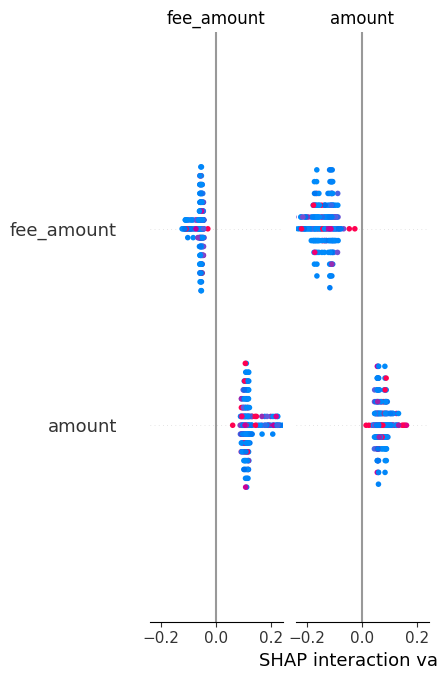

In [93]:
import shap
import numpy as np

X_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# Fix shape issue
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]  # binary classification
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_sample)


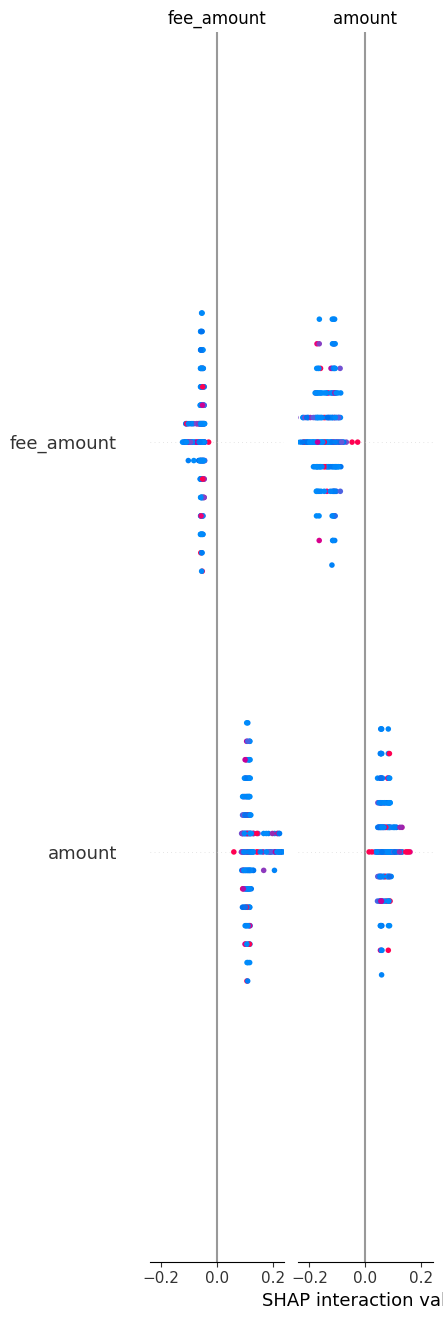

In [94]:
import shap
import numpy as np

X_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15,
    plot_size=(10, 6)
)

### F. FEATURE IMPORTANCE

i. Random Forest Feature Importance

In [95]:
# Random Forest
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

transaction_type_transfer            0.343715
amount_vs_avg                        0.137291
amount                               0.113428
fee_amount                           0.085522
user_avg_amount                      0.083318
fraud_high_value                     0.056226
user_txn_count                       0.052500
transaction_type_bill_payment        0.038355
transaction_type_merchant_payment    0.036616
transaction_value_High value         0.011195
dtype: float64


ii. Gradient Boosting Feature Importance

In [96]:
# Gradient Boosting
import pandas as pd

importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(10))

fraud_high_value             0.372834
transaction_type_transfer    0.275881
amount_vs_avg                0.177265
amount                       0.103780
user_avg_amount              0.031067
fee_amount                   0.020595
user_txn_count               0.007713
country_Nigeria              0.005451
country_Kenya                0.002675
device_type_iOS              0.002190
dtype: float64


iii. SHAP Feature Importance

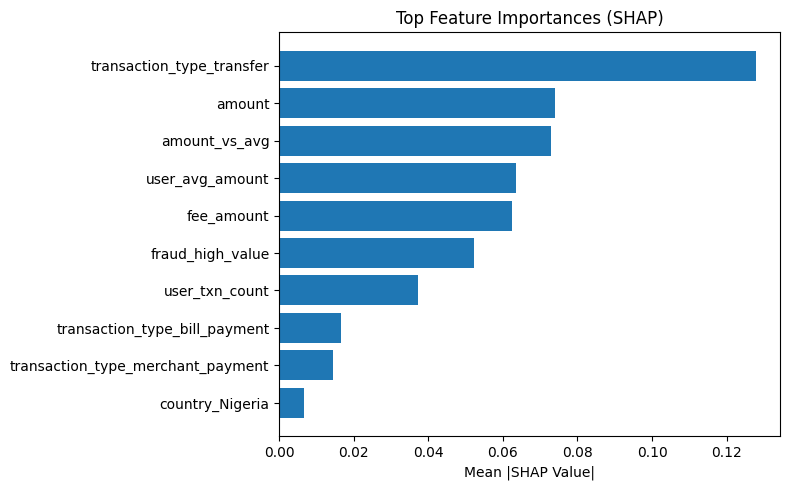

In [97]:
# Force proper numpy array
shap_values = np.array(shap_values)

# Collapse to 2D if needed
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

# Compute mean importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# 🔥 CRITICAL: Force 1D
mean_abs_shap = np.ravel(mean_abs_shap)

# Feature names
feature_names = X_sample.columns

# Align safely
min_len = min(len(mean_abs_shap), len(feature_names))
mean_abs_shap = mean_abs_shap[:min_len]
feature_names = feature_names[:min_len]

# Create dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": mean_abs_shap
}).sort_values(by="Importance", ascending=False)

# Plot
top_n = 10
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"].head(top_n)[::-1],
    importance_df["Importance"].head(top_n)[::-1]
)
plt.title("Top Feature Importances (SHAP)")
plt.xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()

### G. SAVE BEST MODEL

In [98]:
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score

def save_best_model(models_dict, X_test, y_test, X_train, save_path="best_model.pkl"):
    best_score = -1
    best_model = None
    best_name = ""

    for name, model in models_dict.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        score = roc_auc_score(y_test, y_proba)

        if score > best_score:
            best_score = score
            best_model = model
            best_name = name

    print(f"✅ Best model: {best_name} | ROC AUC: {best_score:.4f}")

    # 🔥 Find best threshold
    from sklearn.metrics import precision_recall_curve
    import numpy as np

    y_proba = best_model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    print(f"✅ Best threshold: {best_threshold:.4f}")

    # ✅ Save EVERYTHING together
    joblib.dump({
        "model": best_model,
        "threshold": best_threshold,
        "columns": X_train.columns.tolist()
    }, save_path)

    print("✅ Model bundle saved successfully")


# Run this
models = {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "Gradient Boost": gb
}

save_best_model(models, X_test, y_test, X_train)

✅ Best model: Gradient Boost | ROC AUC: 0.9107
✅ Best threshold: 0.0784
✅ Model bundle saved successfully


Export clean dataset for visualization

In [99]:
df.to_csv('clean_fintech_dataset.csv', index=False)

# =============================================

## 📊 Key Insights

---

### 🔍 Fraud Behavior Insights

#### 1. High-Value Transactions Are Riskier
- Transactions above a defined threshold ($1,500) show significantly higher fraud probability  
👉 Fraudsters tend to target **large-value payouts**

---

#### 2. Failed Transactions Signal Fraud Attempts
- Repeated failed transactions are strongly correlated with fraud  
👉 Indicates **brute-force attempts** or **system probing behavior**

---

#### 3. Geographic Fraud Patterns
- Fraud rates vary significantly across countries  
👉 Suggests **geo-based fraud hotspots** that require targeted controls  

---

#### 4. Transaction Type & Device Type Risk Exposure
- Transfer transactions & Web-based transactions show highest fraud rates  
👉 Likely due to **lower security environments**

---

#### 5. Transaction Behavior Patterns
- Fraudulent activity often involves **unusual frequency or rapid attempts**  
👉 Indicates need for **velocity-based monitoring rules**

---

### 📉 Retention Insights (Integrated)

#### 6. Sharp Drop After Month 1
- Retention drops significantly after the first month  

👉 Meaning:
- Weak early user engagement  
- Poor onboarding experience  

---

#### 7. Stabilization After Initial Drop
- Retention stabilizes after Month 2  

👉 Meaning:
- Remaining users are **high-value and loyal users**  

---

#### 8. Retention is Consistent Across Segments
- Country (~76%), Device (~75–77%), and Channel (~75–76%) show minimal variation  

👉 Meaning:
- Retention problem is **product-wide**, not segment-specific  
- User churn is driven by **experience, not demographics or acquisition source**

---

#### 9. Acquisition Quality is Not the Problem
- Organic, Ads, and Referral users retain at similar rates  

👉 Meaning:
- The issue lies in **post-acquisition experience**, not marketing quality  

---

#### 10. Long-Term Retention is Low
- Few users remain active over time  

👉 Meaning:
- Product lacks **long-term stickiness and engagement drivers**

---

## 🤖 Model Insights

---

#### 1. Class Imbalance Impact
- Fraud cases are significantly fewer than non-fraud cases  
- Creates bias toward predicting non-fraud  

✅ Addressed using:
```python
class_weight = 'balanced'
```


### 2. ROC AUC as Primary Metric
- Accuracy alone is misleading in imbalanced datasets  
- ROC AUC better measures fraud detection performance  

---

### 3. Model Limitation
- Model performance depends heavily on feature quality  
👉 Lack of behavioral features limits predictive power  

---

## Executive Summary

This project developed a machine learning-powered fraud detection system capable of identifying high-risk transactions in real time.

### Fraud Insights:
- Fraud is driven by high-value transactions, failed attempts, and transaction/device patterns  

### Retention Insights:
- Users churn early, and retention is consistent across all segments  
- Indicates a **product experience issue rather than acquisition or demographic factors**

## 🧾 Conclusion

This project demonstrates an end-to-end fintech analytics workflow, combining data analysis, machine learning, and business intelligence to address critical challenges in fraud detection and customer retention.

Key findings reveal that fraud is driven by high-value and anomalous transaction behavior, while retention issues stem from early-stage user experience rather than acquisition channels.

Overall, the project highlights the importance of leveraging data-driven insights to build secure, scalable, and user-centric fintech systems.